# GPT-4o

In [ ]:
GROUP_NAME = "gpt-4o-2024-08-06-gaze2"
RESULT_PATH = "../output/result_1766691418_20251124F_20260101F_20251123_20251124.csv"

## Setup

In [2]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance", "tidyr", "car")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("ggeffects", "strengejacke/ggeffects")

utils:::print.sessionInfo(sessionInfo()[-c(10,12,13)])

Loading required package: Matrix


Attaching package: ‘marginaleffects’


The following object is masked from ‘package:lme4’:

    refit



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sequoia 15.6.1

Matrix products: default


locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Asia/Shanghai
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        car_3.1-3              carData_3.0-5         
 [4] tidyr_1.3.2            performance_0.15.3     parameters_0.28.3     
 [7] dplyr_1.1.4            ggplot2_4.0.1          marginaleffects_0.31.0
[10] readr_2.1.6            lme4_1.1-38            Matrix_1.7-4          


In [3]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor()))
df <- df[df$Group == GROUP_NAME, ]
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

## On Stimuli B (Hypothesis-Driven)

In [4]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_unnatural <- df_B %>%
  filter(Condition %in% c("congruent", "incongruent")) %>% 
  mutate(offset_wrongness_head = qlogis(ExpectedDistToHeadTarget / MaxDistToHeadTarget),)
df_replicate <- df_B[df_B$Condition != "incongruent", ]

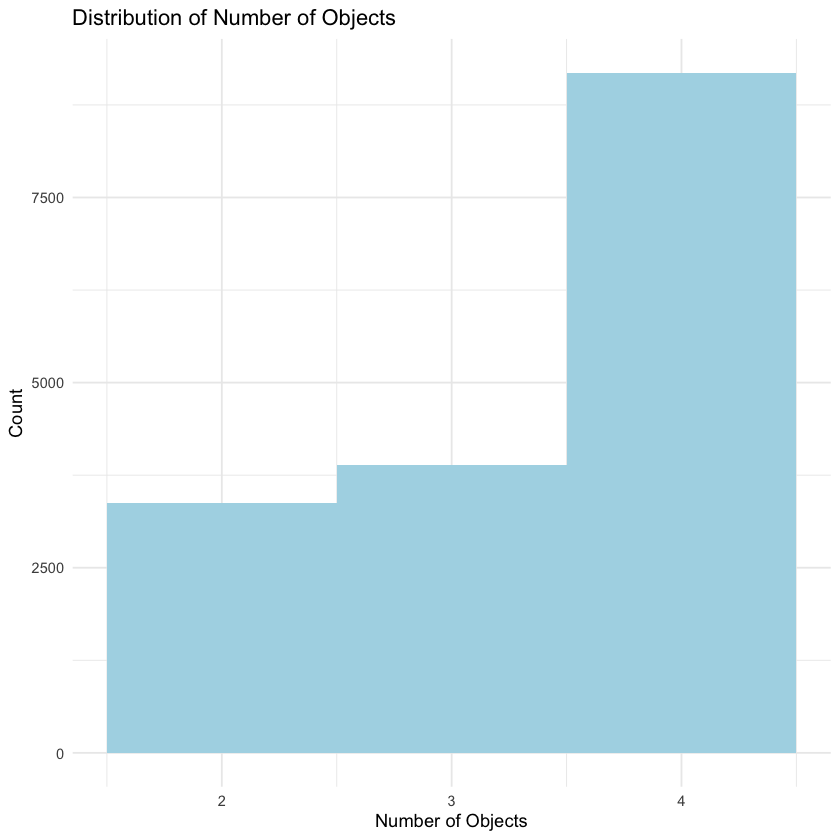

In [5]:
ggplot(df_unnatural, aes(x = n_candidates)) +
    geom_histogram(binwidth = 1, fill = "lightblue") +
    theme_minimal() +
    labs(
        title = "Distribution of Number of Objects",
        x = "Number of Objects",
        y = "Count"
    )

### Replicating the Proximity effect and the (lack of) View effect

In [6]:
m_effects1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
m_effects2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
m_effects3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
m_effects4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
isSingular(m_effects1)
isSingular(m_effects2)
isSingular(m_effects3)
isSingular(m_effects4)
compare_performance(m_effects1, m_effects2, m_effects3, m_effects4, rank = TRUE)

[1] FALSE

[1] FALSE

[1] FALSE

[1] FALSE

Some of the nested models seem to be identical and probably only vary in
  their random effects.

Following indices with missing values are not used for ranking: Sigma,
  Log_loss



Name,Model,R2_conditional,R2_marginal,ICC,RMSE,Sigma,Log_loss,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects1,glmerMod,0.6710227,0.04283788,0.6562993,0.2565923,1,NA,0.07251449,0.07197948,9.320199e-05,0.5709415
m_effects4,glmerMod,0.6709829,0.04279809,0.6562720,0.2566097,1,NA,0.53394753,0.53537557,9.807852e-01,0.4300603
m_effects2,glmerMod,0.6710002,0.04279777,0.6562902,0.2565924,1,NA,0.19682785,0.19638121,9.563666e-03,0.3776356
m_effects3,glmerMod,0.6710053,0.04283802,0.6562810,0.2566097,1,NA,0.19671012,0.19626374,9.557945e-03,0.3484172


In [7]:
m_effects_c <- m_effects1

In [8]:
avg_slopes(m_effects_c, variables = "Proximity")
avg_slopes(m_effects_c, variables = "n_candidates")
avg_comparisons(m_effects_c, variables = "Angle")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.06827461,0.01490314,4.581223,4.622642e-06,17.72285,0.03906499,0.09748422


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,0.02788012,0.01450071,1.922673,0.05452116,4.19704,-0.0005407494,0.05630098


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.05482734,0.03032044,1.8082633,0.07056554,3.824892,-0.004599632,0.11425430
Angle,right - front,0.02224785,0.02994715,0.7429037,0.45753996,1.128030,-0.036447486,0.08094319


In [9]:
m_effects <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
anova(m_effects, m_effects_c)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects,9,14189.36,14254.75,-7085.682,14171.36,NA,NA,NA
m_effects_c,27,14217.46,14413.61,-7081.728,14163.46,7.907742,18,0.9799784


In [11]:
### Report
summary(m_effects)
Anova(m_effects, type = 3)
vc_list <- lapply(VarCorr(m_effects), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(m_effects)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

# The below code is for generating the table in the paper.
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

#actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
#actory_est <- res[res$term == actory_term_name, "Estimate"]
#actory_se <- res[res$term == actory_term_name, "Std. Error"]
#actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
#actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("View=left", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("View=right", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size))

    #c("ActorY", "b", sprintf("%.7f", actory_est)),
    #c("", "SE", sprintf("%.7f", actory_se)),
    #c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    #c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    Condition + offset(offset_wrongness) + (1 | Stimulus_ID) +  
    (1 | Candidates) + (1 | Prompt_ID)
   Data: df_replicate
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
  14189.4   14254.7   -7085.7   14171.4     10551 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.4397 -0.4068 -0.1574  0.2645  4.9853 

Random effects:
 Groups      Name        Variance  Std.Dev.
 Stimulus_ID (Intercept) 3.502e+00 1.871459
 Prompt_ID   (Intercept) 1.164e-04 0.010787
 Candidates  (Intercept) 5.234e-05 0.007235
Number of obs: 10560, groups:  Stimulus_ID, 660; Prompt_ID, 16; Candidates, 13

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)     

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),44.425854225,1,2.641752e-11
"scale(Proximity, scale = FALSE)",23.256764560,1,1.417510e-06
Angle,3.555861239,2,1.689875e-01
"scale(n_candidates, scale = FALSE)",3.260725697,1,7.095772e-02
Condition,0.005405814,1,9.413890e-01


term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.01880920,0.15285335,-6.66527225,0.00000000002641752,-1.31840177,-0.7192166,2.606223,-0.390914101
"scale(Proximity, scale = FALSE)",0.45623294,0.09460454,4.82252678,0.00000141750989921,0.27080804,0.6416578,2.606223,0.175055242
Angleleft,0.35370136,0.18851550,1.87624546,0.06062158236134799,-0.01578903,0.7231917,2.606223,0.135714173
Angleright,0.14324955,0.18834379,0.76057484,0.44691105394126174,-0.22590428,0.5124034,2.606223,0.054964432
"scale(n_candidates, scale = FALSE)",0.16324269,0.09040170,1.80574796,0.07095771741540899,-0.01394465,0.3404300,2.606223,0.062635740
Conditioncongruent,0.01133794,0.15420683,0.07352424,0.94138895235797593,-0.29090745,0.3135833,2.606223,0.004350335


3.5023599
NA
0.0001164
2.6062227
-1.0188092
0.1528534
0.3537014
0.1885155
0.0606216
0.1357142
0.1432495
0.1883438
0.4469111
0.0549644
0.4562329
0.0946045
0.0000014
0.1750552
0.1632427
0.0904017
0.0709577
0.0626357


### Test 2.1: Choose head targets more↑ often than gaze targets (when they differ).
Take results in the Incongruent Condition with #Objects greater than 2 and the responded object being either GazeTarget or HeadTarget. Fit a model with “IsHeadTarget ~ 1 + (1 | Objects) + (1 | StimulusID) + (1 | PromptID)” for each VLM. A significant positive intercept indicates a positive answer.

In [28]:
df_test21 <- df_B %>%
  filter(
    Condition == "incongruent",
    n_candidates > 2,
    (Choice == HeadTarget | Choice == label) # Keep only trials where the choice was one of the two cues
  )

mean(df_test21$IsHeadTarget)
m_head_bias <- glmer(
  as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID) + (1 | Prompt_ID),
  data = df_test21, 
  family = binomial,
  control = strict_control
)
summary(m_head_bias)

[1] 0.5338414

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID) + (1 | Prompt_ID)
   Data: df_test21
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
   4110.6    4130.5   -2052.3    4104.6      5508 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.7749 -0.1903  0.1205  0.2660  3.5716 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 16.01085 4.001   
 Prompt_ID   (Intercept)  0.01489 0.122   
Number of obs: 5511, groups:  Stimulus_ID, 528; Prompt_ID, 16

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)   0.3527     0.1901   1.855   0.0636 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [14]:
1 / (1 + exp(-0.3527))

[1] 0.5872722

In [15]:
stimulus_means <- df_test21 %>%
  group_by(Stimulus_ID) %>%
  summarize(n = n())
table(stimulus_means$n)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16 
 36  32  23  20  17  17  19  24  17  26  19  26  30  33  60 129 

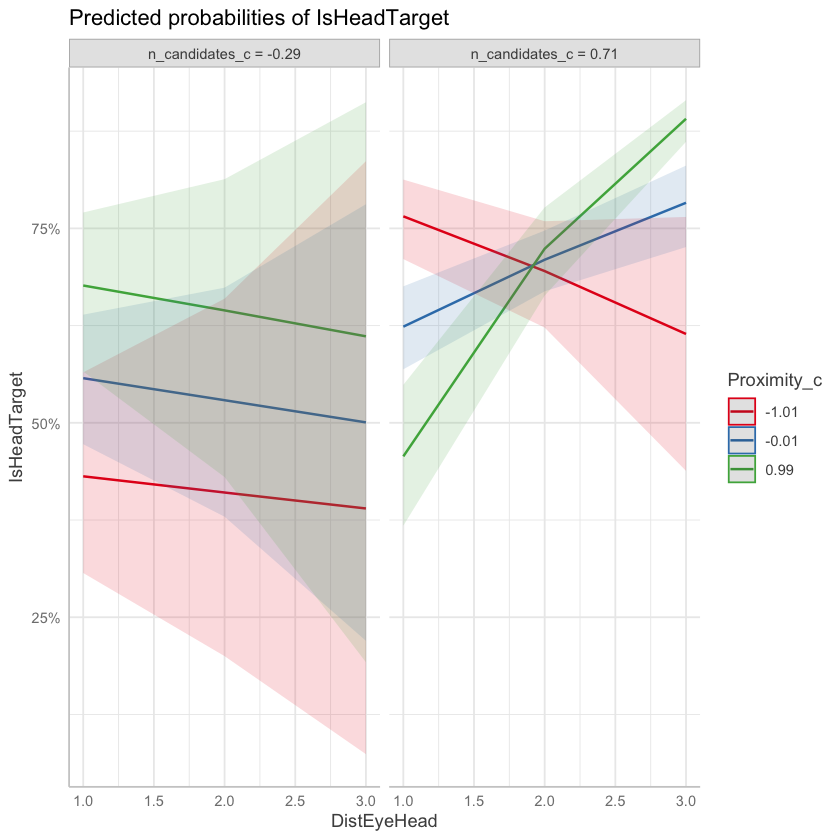

In [22]:
#plot(ggpredict(
#  m_head_bias, 
#  terms = c("DistEyeHead [all]", "Proximity_c [all]", "n_candidates_c [all]")
#))

### Test 2.2: When head orientation is fixed but only eye appearance varies, responses stay the same much more often than chance?
Take results in the Congruent and Incongruent Conditions. Fix a combination of (#Objects, Objects, Proximity, View, HeadTarget, PromptID), vary only GazeTarget (2-4 levels). Calculate the number of combinations where the Choice stays the same. Compare the rate of such to chance using a directional one-sample t-test. Rejecting the null hypothesis indicates a positive answer.

In [29]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1 & first(IsHeadTarget) == TRUE, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 0)
  )

cat("Actual Stability Rate (choosing headtarget): ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate (choosing headtarget):  0.2693318 
Random Chance Baseline: 0.09560342 



	One Sample t-test

data:  diff_scores
t = 30.56, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.1643762       Inf
sample estimates:
mean of x 
0.1737284 


In [30]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 1)
  )

cat("Actual Stability Rate: ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate:  0.5454204 
Random Chance Baseline: 0.203735 



	One Sample t-test

data:  diff_scores
t = 51.394, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.3307479       Inf
sample estimates:
mean of x 
0.3416854 


### Test 2.3: Performance when the HeadTarget = the GazeTarget is much higher↑ than when they differ?
Take results in the Congruent and Incongruent Conditions. Fit “IsCorrect ~ Proximity * View * #Object  * Condition + (1|Random Effects)” with offset being the chance accuracy. If the marginal prediction of Condition indicates that accuracy is higher in the congruent condition than in the incongruent condition, then this claim is supported.

In [31]:
mean(df_B[df_B$Condition == "congruent", ]$Accuracy)
mean(df_B[df_B$Condition == "incongruent", ]$Accuracy)

[1] 0.4470274

[1] 0.2928571

In [33]:
model_cond <- glmer(Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_accuracy) + (1|Stimulus_ID) + (1|Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
isSingular(model_cond)

[1] FALSE

In [41]:
model_cond

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition +  
    offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID)
   Data: df_unnatural
      AIC       BIC    logLik -2*log(L)  df.resid 
12716.496 12916.903 -6332.248 12664.496     16422 
Random effects:
 Groups      Name        Std.Dev.
 Stimulus_ID (Intercept) 2.99512 
 Prompt_ID   (Intercept) 0.07498 
Number of obs: 16448, groups:  Stimulus_ID, 1028; Prompt_ID, 16
Fixed Effects:
                                               (Intercept)  
                                                 -0.070214  
                                               Proximity_c  
                                                 -0.262941  
                                                 Angleleft  
                                                 -0.550462  
                                                Ang

In [36]:
avg_predictions(model_cond, variables = "Condition")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Condition,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
congruent,0.4077217,0.01963471,20.76535,8.907065e-96,315.7501,0.3692383,0.4462050,Inf
incongruent,0.2975786,0.01341993,22.17438,6.070525e-109,359.4883,0.2712760,0.3238812,Inf


In [37]:
avg_predictions(model_cond, variables = "Condition", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(incongruent) - (congruent),-0.1101431,0.02362127,-4.662877,3.118196e-06,18.29086,-0.1564399,-0.06384623,Inf


### Test 2.4: Fix the GazeTarget, as the HeadTarget moves farther away from the GazeTarget, their responses also move farther away from the GazeTarget?

Here, the distance is one plus the number of objects between them.
Take results in the Congruent and Incongruent Conditions. Fit “cbind(Wrongness, MaxWrongness - Wrongness) ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects)” with offset again being the chance baseline. If the marginal slope indicates that as DistEyeHead increases, the relative Wrongness also increases, then the answer is yes.

In [34]:
m_dist <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)

In [38]:
avg_slopes(m_dist, variables = "DistEyeHead")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.09473532,0.01174224,8.067907,7.151362e-16,50.31263,0.07172095,0.1177497


In [42]:
exp(0.09473532	)

[1] 1.099368

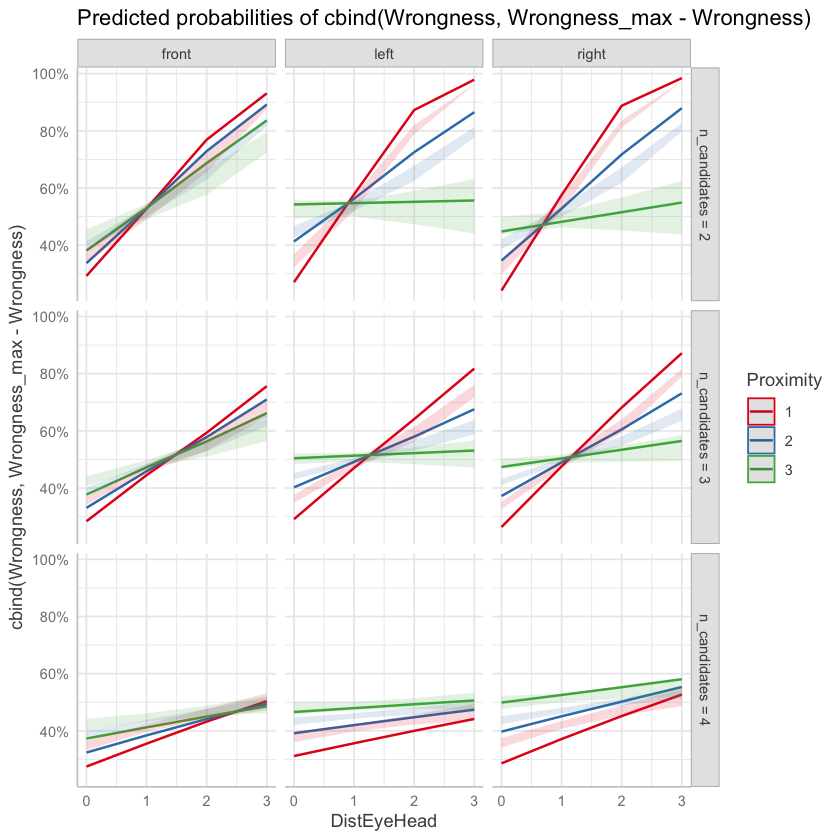

In [39]:
plot(ggpredict(
  m_dist, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]"),
  bias_correction = TRUE
))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


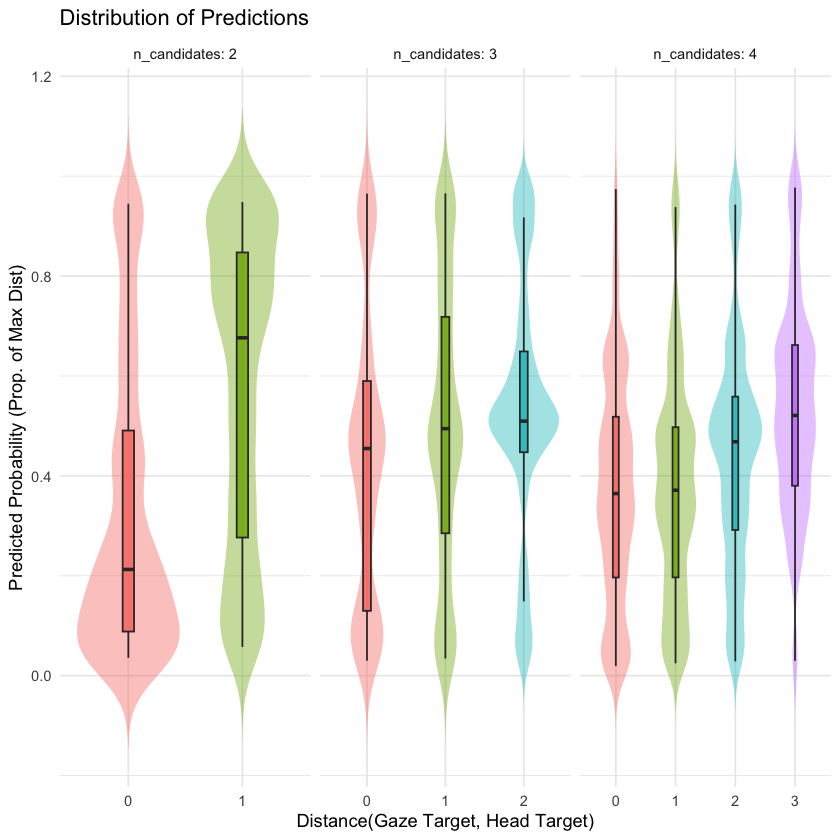

In [45]:
valid_grid <- df_unnatural %>%
    distinct(Proximity, Angle, DistEyeHead, n_candidates, offset_wrongness, Stimulus_ID, Prompt_ID, Candidates)
preds <- predictions(m_dist, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)

ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
#  geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


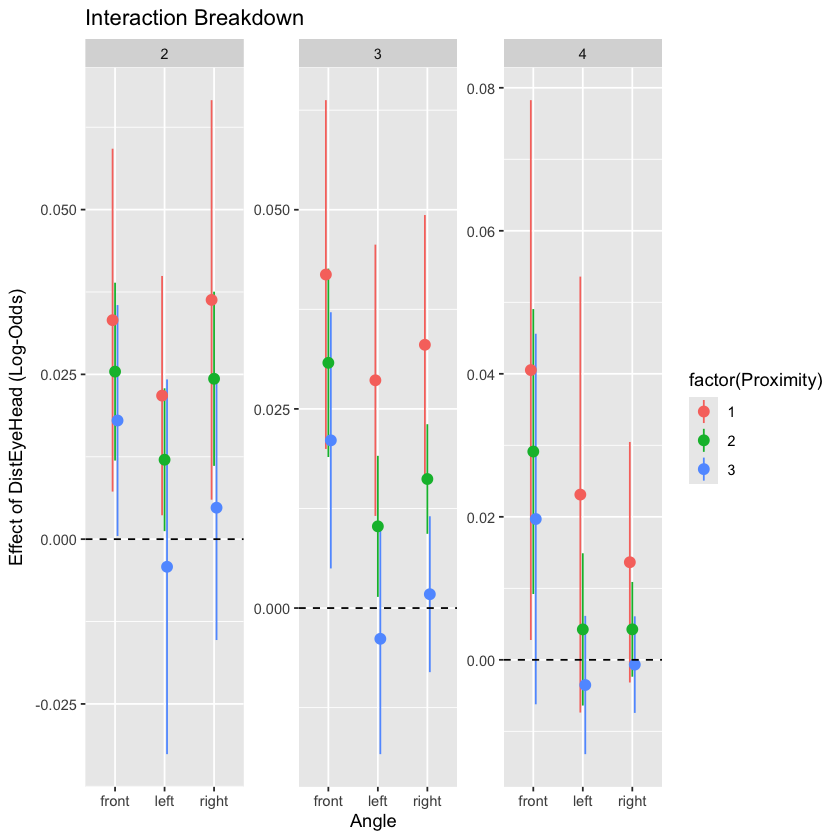

In [ ]:
plot_slopes(
  m_dist,
  variables = "DistEyeHead",
  condition = c("Angle", "Proximity", "n_candidates") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of DistEyeHead (Log-Odds)", title = "Interaction Breakdown")

In [ ]:
avg_slopes(m_dist, variables = "DistEyeHead", by = "Proximity")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,1,0.17163805,0.02174558,7.893009,2.949858e-15,48.268276,0.129017497,0.21425859
DistEyeHead,dY/dX,2,0.09442985,0.01342333,7.034757,1.996088e-12,38.865962,0.068120608,0.12073909
DistEyeHead,dY/dX,3,0.03272974,0.01981832,1.651489,9.863882e-02,3.341701,-0.006113463,0.07157294


In [75]:
avg_slopes(m_dist, variables = "DistEyeHead", by = "Proximity", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(2) - (1),-0.05295517,0.01420383,-3.728232,0.0001928278,12.34040,-0.08079416,-0.02511618
(3) - (1),-0.10307211,0.02843078,-3.625371,0.0002885472,11.75890,-0.15879541,-0.04734881
(3) - (2),-0.05011694,0.01435608,-3.490991,0.0004812327,11.02098,-0.07825434,-0.02197954


In [ ]:
avg_slopes(m_dist, variables = "DistEyeHead", by = "Angle", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),-0.11834631,0.03446003,-3.434306,0.0005940728,10.717073,-0.1858867,-0.05080588
(right) - (front),-0.08127382,0.03359704,-2.419077,0.0155599439,6.006019,-0.1471228,-0.01542484
(right) - (left),0.03707249,0.02878537,1.287894,0.1977830270,2.338009,-0.0193458,0.09349078


### Test 3: Fix the HeadTarget. As the GazeTarget moves farther away from the HeadTarget, do their responses move farther away from the HeadTarget?
Take results in the Congruent and Incongruent Conditions. Fit “cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ Proximity * Angle * #Objects * DistEyeHead + (1|Random Effects)” with offset being the chance baseline logit(ExpectedDistToHeadTarget / MaxDistToHeadTarget). If the marginal slope indicates that as DistEyeHead increases, the relative DistToHeadTarget also increases, then the answer is yes.

In [46]:
m_head <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1|Stimulus_ID) + (1|Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)

In [48]:
avg_slopes(m_head, variables = "DistEyeHead")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.04244066,0.01197722,3.543447,0.0003949331,11.3061,0.01896573,0.06591559


In [52]:
exp(0.04244066)

[1] 1.043354

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


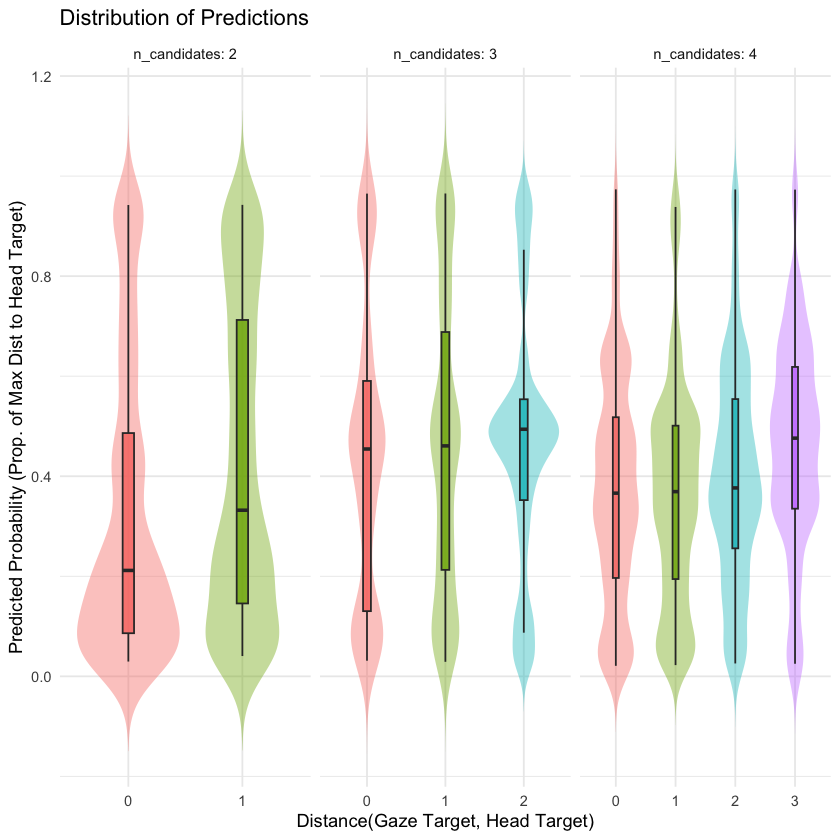

In [49]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_wrongness_head, Stimulus_ID, Prompt_ID, Candidates)
preds <- predictions(m_head, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
#  geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist to Head Target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

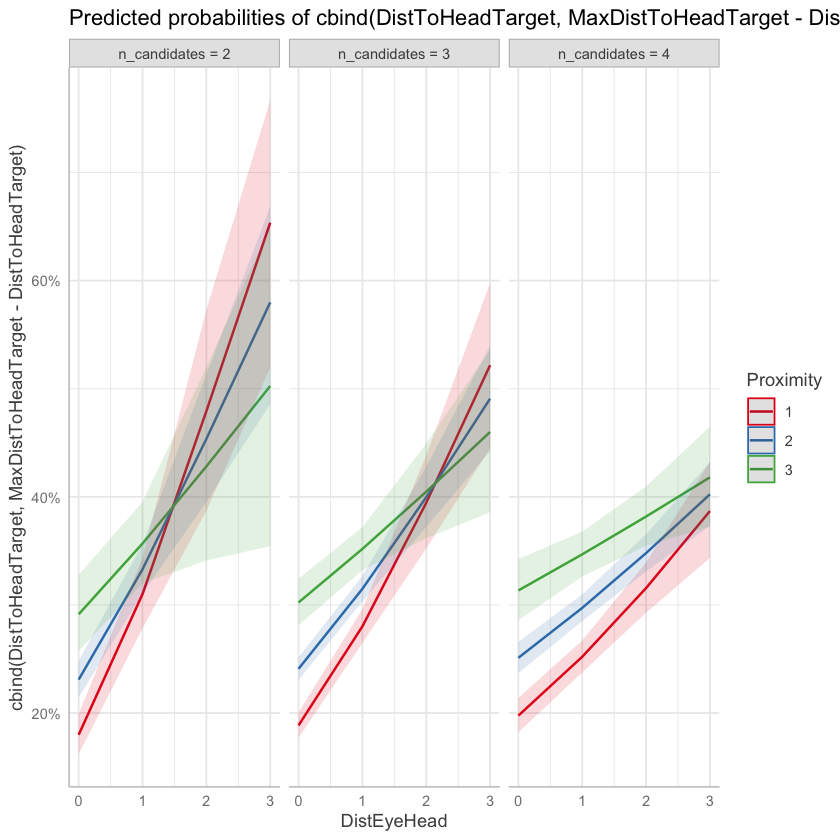

In [50]:
plot(ggpredict(
  m_head, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "n_candidates [all]")
))

### Test 4: How exactly does Frequency(response=head target) correlate with distance(head target, gaze target)? 
This will distinguish between Possibilities 4 & 5. Possibility 4 predicts that Frequency(response=head target) correlates negatively with distance(head target, gaze target), while Possibility 5 predicts that Frequency(response=head target) jumps down only when distance(head target, gaze target) goes from 0 to 1, but stays the same after that. If the relation turns out not to be a negative correlation, then these two explanations are incomplete. 

Take results in the Congruent and Incongruent Conditions with #Objects greater than 2. Fit “IsHeadTarget ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects).” Here, DistEyeHead is treated as categorical. Separately looking at #Object=3 and 4, the marginal means of IsHeadTarget for DistEyeHead=1 and 2 (or 1, 2, and 3 for #Object=4) are not significantly different from each other, but are all significantly lower than when DistEyeHead=0, then Possibility 5 is supported. Otherwise, if the marginal mean in general decreases, then Possibility 4 is supported.

In [59]:
m_3obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID), data = df_unnatural[df_unnatural$n_candidates == 3, ], family = binomial, control = strict_control)

In [61]:
m_4obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID), data = df_unnatural[df_unnatural$n_candidates == 4, ], family = binomial, control = strict_control)

In [62]:
avg_predictions(m_3obj, variables = "DistEyeHead", hypothesis = ~ pairwise)
avg_predictions(m_4obj, variables = "DistEyeHead", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),0.01927582,0.05417258,0.3558224,0.721973576,0.4699821,-0.0869005,0.12545213,Inf
(2) - (0),-0.13415355,0.05951931,-2.2539499,0.024199320,5.3688897,-0.2508093,-0.01749784,Inf
(2) - (1),-0.15342937,0.05657555,-2.7119379,0.006689113,7.2239694,-0.2643154,-0.04254333,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),0.02787453,0.03934512,0.7084620,0.4786583731,1.062932,-0.0492405,0.104989545,Inf
(2) - (0),-0.03874697,0.04169172,-0.9293683,0.3526982276,1.503494,-0.1204612,0.042967307,Inf
(3) - (0),-0.13052883,0.04452074,-2.9318655,0.0033693265,8.213324,-0.2177879,-0.043269776,Inf
(2) - (1),-0.06662149,0.03799473,-1.7534405,0.0795264258,3.652422,-0.1410898,0.007846804,Inf
(3) - (1),-0.15840335,0.04106173,-3.8576881,0.0001144646,13.092811,-0.2388829,-0.077923839,Inf
(3) - (2),-0.09178186,0.04329859,-2.1197424,0.0340277778,4.877143,-0.1766455,-0.006918179,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


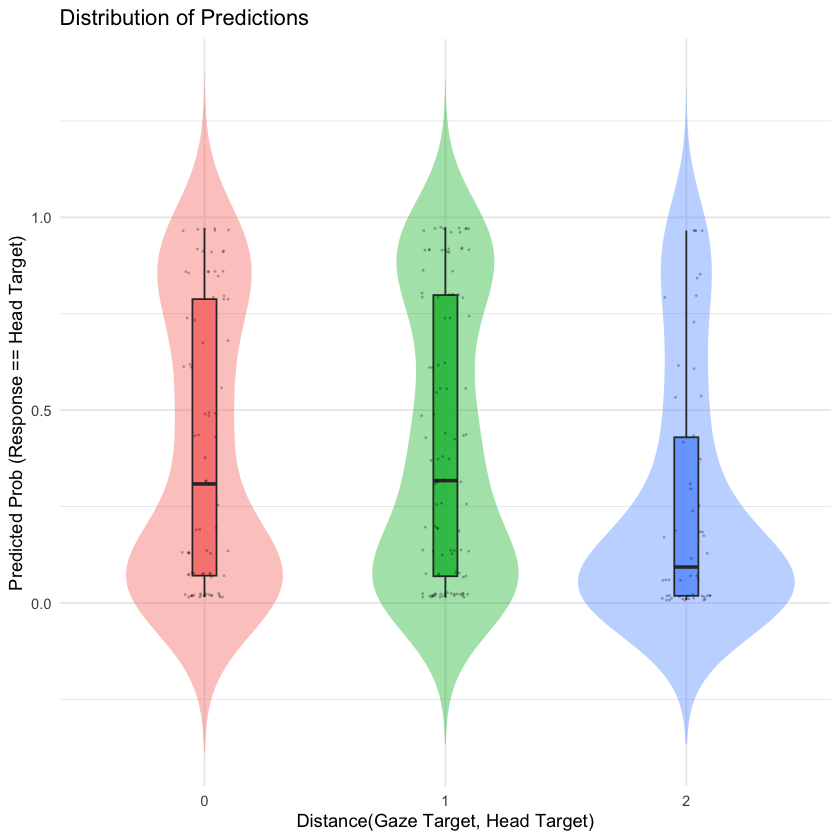

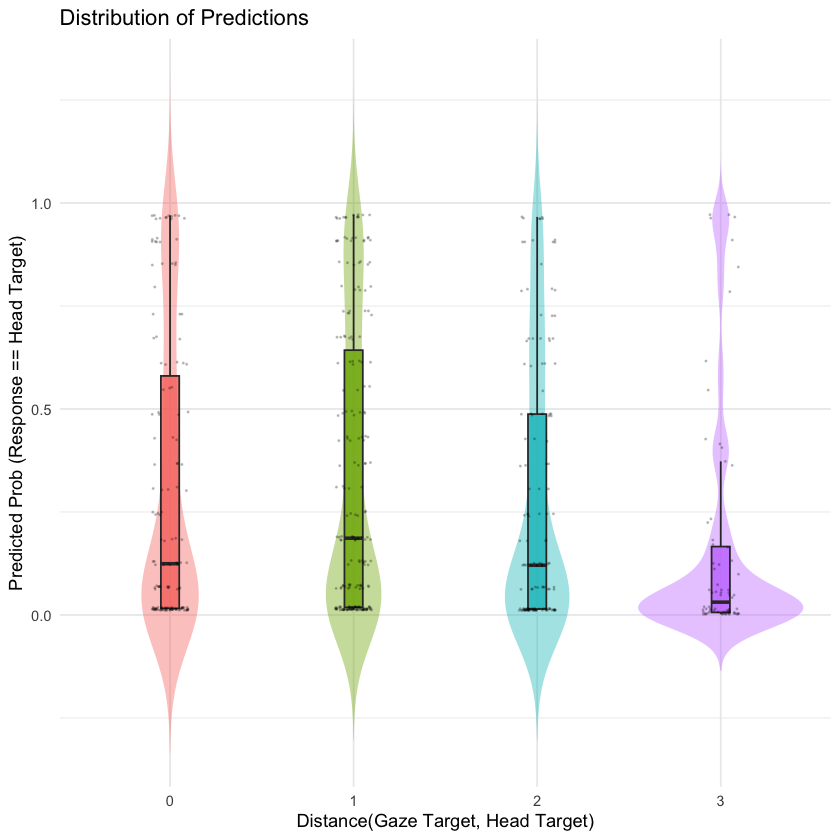

In [63]:
plot_head_preds <- function(model, data, x_var = "DistEyeHead", facet_var = NULL) {
  
  # 1. Define the columns we absolutely need for the prediction grid
  #    (Predictors + Random Effect Group + Offset)
  needed_cols <- c(x_var, "Candidates", "Proximity", "Angle", "offset_accuracy", "Stimulus_ID")
  if (!is.null(facet_var)) needed_cols <- c(needed_cols, facet_var)
  
  # 2. Create the valid_grid
  #    We use distinct() to avoid predicting on 20,000 rows if we only need
  #    unique condition+candidate combinations.
  valid_grid <- data %>%
    select(all_of(intersect(needed_cols, names(data)))) %>%
    distinct()
  
  # 3. Generate Predictions
  #    type="response" ensures we get probabilities (0-1)
  preds <- predictions(model, newdata = valid_grid, type = "response")
  
  # 4. Prepare for plotting
  #    Convert x_var to factor so violin plots work properly
  preds[[x_var]] <- as.factor(preds[[x_var]])
  
  # 5. Build the Plot
  p <- ggplot(preds, aes(x = .data[[x_var]], y = estimate, fill = .data[[x_var]])) +
    # The Violin: Density across items
    geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
    
    # The Boxplot: Summary stats
    geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
    
    # Jitter: Individual item points
    geom_jitter(width = 0.1, alpha = 0.2, size = 0.2) +
    
    # Labels
    labs(
      x = "Distance(Gaze Target, Head Target)",
      y = "Predicted Prob (Response == Head Target)",
      title = "Distribution of Predictions"
    ) +
    theme_minimal() +
    theme(legend.position = "none")
  
  # 6. Add Faceting conditionally
  if (!is.null(facet_var)) {
    p <- p + facet_wrap(as.formula(paste("~", facet_var)), 
                        labeller = label_both, 
                        scales = "free_x")
  }
  
  return(p)
}

plot_head_preds(
  model = m_3obj, 
  data = df_unnatural[df_unnatural$n_candidates == 3, ]
)
plot_head_preds(
  model = m_4obj, 
  data = df_unnatural[df_unnatural$n_candidates == 4, ]
)

Ignoring unknown labels:
• linetype : "DistEyeHead"
• shape : "DistEyeHead"


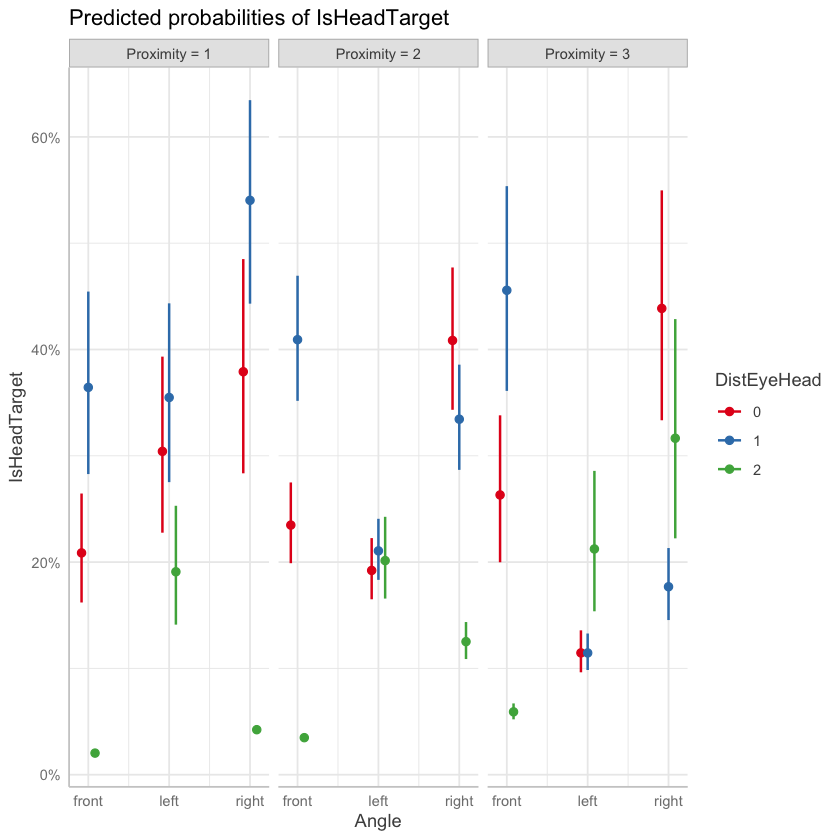

In [64]:
plot(ggpredict(
  m_3obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

Ignoring unknown labels:
• linetype : "DistEyeHead"
• shape : "DistEyeHead"


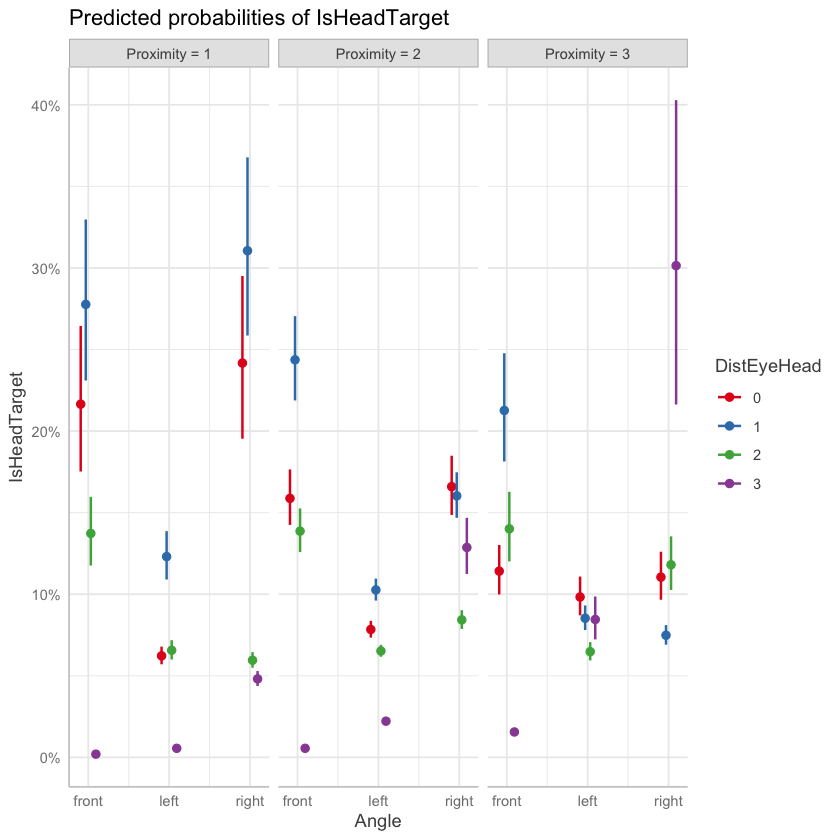

In [65]:
plot(ggpredict(
  m_4obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

## Exploratory

In [ ]:
df_view <- df_B %>%
  mutate(DistEyeHead = factor(replace_na(DistEyeHead, -1)))

### An Overview

In [66]:
m_plot <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Site) + (1 | Site: Candidates), data = df_B, family = binomial, control = strict_control)

In [ ]:
m_plot

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


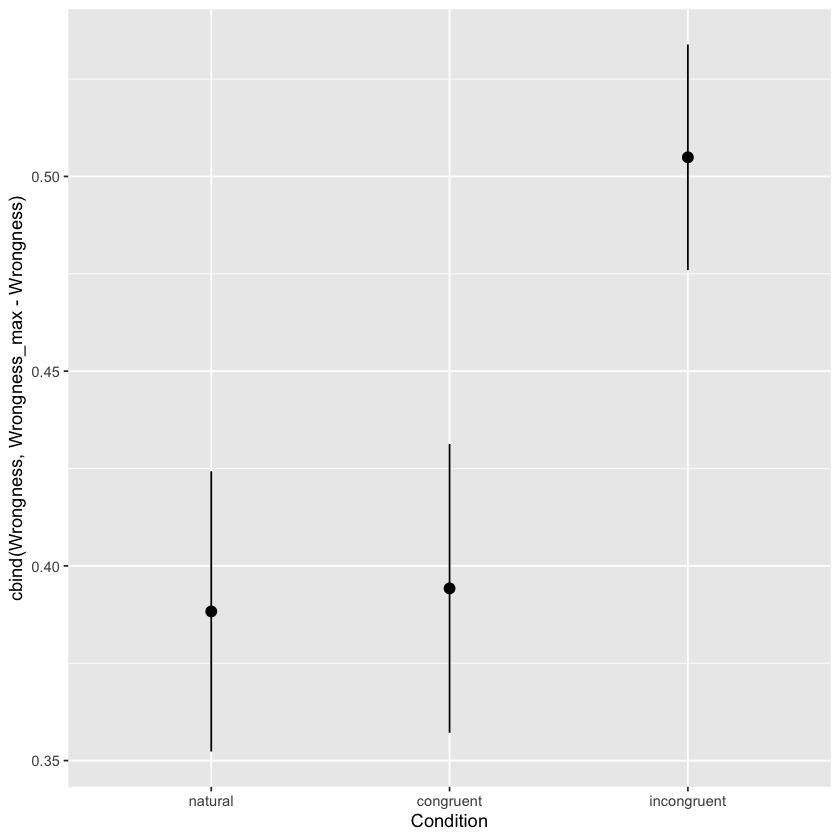

In [ ]:
plot_predictions(m_plot, by = c("Condition"))

In [67]:
plot_predictions(m_plot, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))
plot_predictions(m_plot, by = c("Angle"))
plot_predictions(m_plot, by = c("Candidates")) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
plot_predictions(m_plot, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))
plot_predictions(m_plot, by = c("Prompt_ID"))

ERROR: Error: object 'm_plot' not found


### Site difference

In [72]:
m_site <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Site * Proximity_c + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Site: Candidates), data = df_B, family = binomial, control = strict_control)

In [74]:
summary(m_site)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ Site * Proximity_c +  
    offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) +  
    (1 | Site:Candidates)
   Data: df_B
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
  31678.0   31733.9  -15832.0   31664.0     21753 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.5795 -0.4168 -0.0085  0.3557  4.8682 

Random effects:
 Groups          Name        Variance  Std.Dev.
 Stimulus_ID     (Intercept) 3.2838444 1.81214 
 Prompt_ID       (Intercept) 0.0005431 0.02331 
 Site:Candidates (Intercept) 0.0101361 0.10068 
Number of obs: 21760, groups:  
Stimulus_ID, 1360; Prompt_ID, 16; Site:Candidates, 13

Fixed effects:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)           -0.51009    0.08200  -6.220 4.96e-10 ***
SiteSiteH             

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


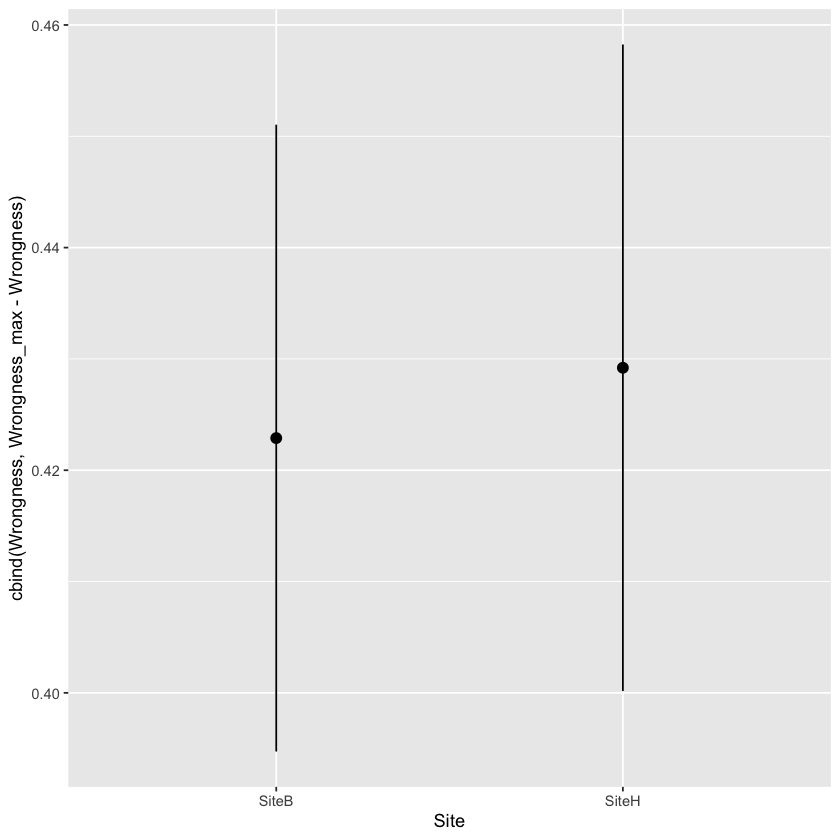

In [73]:
plot_predictions(m_site, by = c("Site"))

### Look at View effects in different conditions

In [ ]:
m_prompt <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Prompt_ID * Angle * DistEyeHead * Proximity_c + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

Warning message in commonArgs(par, fn, control, environment()):
“maxfun < 10 * length(par)^2 is not recommended.”


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


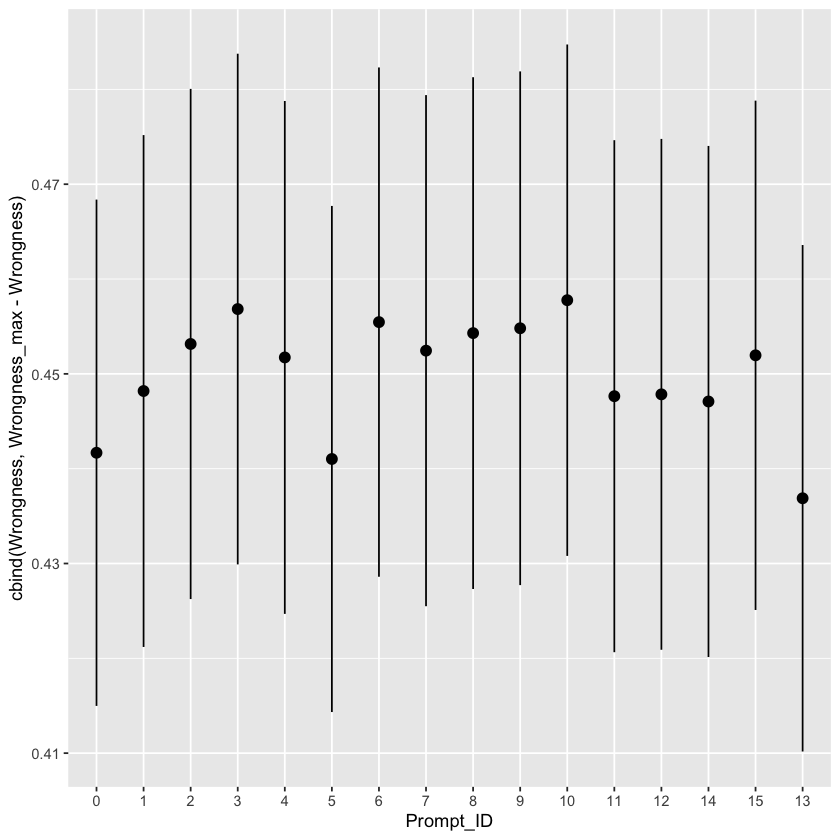

In [ ]:
plot_predictions(m_prompt, by = c("Prompt_ID"))

In [ ]:
model_view_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients



In [ ]:

  
model_view <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

anova(model_view, model_view_c)

In [ ]:
options(repr.plot.width=10, repr.plot.height=6)
plot_slopes(
  model_view_c,
  variables = "Proximity",
  condition = c("DistEyeHead", "n_candidates", "Angle") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

In [ ]:
plot_slopes(
  model_view_c,
  variables = "Angle",
  condition = c("DistEyeHead", "Proximity") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Angle (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()